In [ ]:
# 2200 lines code, 19 solved cases, case 338 is better suited for objective
# cas 338 is a basic in using objective
# cages is depreciated, now, it is time to fix the dimension module
# and hyberdize it with objects related work

In [ ]:
# alright, system is more like of a kluge, 20 tasks caught, hybrid between old and new
# system.
# current goals:
# 1) set_obj_on_train on tasks with no similar dim, mostly undeduced: find how can you
# use core_knowledge on the input to derive output with no similar dim to input
# This is a critical layer of abstraction and must be accomplished
# start with 345, 48, 66, 105, 129, 151, 217, 290

# 2) hook up the edge and the neighbour cases by 
#   1) chekcpoint of whether to go with whatever we have in the objectives
#   or to only apply completed objectives
#   2) massaging the test_objective using the running_objective
#   3) apply test objective using core knowledge on the test inputs to spit test output

# 3) dimension_cognification to use objects, some simple cases were identified
#    here we find the solution and the dimensions instantanously
# 4) add more information from neihgbors.
# 5) 

In [ ]:
# After global objectification and test_expectation, we are confounded and intimidated by how each
# prior-knowledge requires different logic in terms of evaluation, testing, building an output.
# For ex: we need to screen flips, screen dimensions, screen cages: how can these be integrated
# or expressed within the objective system.
# With the objective_oriented approach: we need to massage test_expectations and allow it to work with
# cases in which not is_similar_dim and systems with no global_bg

# Artificial cognition is spider like, prior knowledge can't be looked at similarly, eventhough we did everything
# to decipher some aspects of prior knowledge, but the task in general can abstractedly classified as follows:
# 1) Output = global operation on the entire array ex: flips, dimension contraction, expansion
# 2) Output = leverage of certain attributes of the input array: objectives such as removing noise, edges, nb, dt, object output, etc.
#    output = completed the missing part of input (must conclude of the non-missing part): reflection, etc
# 3) Output = Operation on a certain attribute of the input array: get an object and rotate it 90 degrees

# Probably one way to tackle the above problem is to assume is_similar_dim on all objectives and have an extra
# layer of intelligence to factor in any cognified dimension in a consecutive manner
# As an example: case 345 is based on outputting a single value with edges == 0 (captured), the presence of nil
# in an objective can signal dimesnion work but we need to organize the way the machine thinks

# The goal is build a system that allows the incorporation of prior knowledge without having to modify
# or add anything to the book-keeping logic, this layer of abstraction seems to be what we are hitting at this 
# point. 

# parallel and integrated intelligent circuits
# induction tries to solve the output/dimension simultaneously
# the separation between induction and dimesnionWorks need to be re-evaluated

# We need to include dimension in the objective function not only because
# the system is expected to predict dimensions of the output but also becausue
# dimensions of objects can determine the outputs

# a system that tests flips on the whole array must be capable of exercising the same type
# of tests on objects of the array

# the objective must include dimesnion
# We need more abstraction so as to be able to automate general intelligence
# After satisfying the objective, the hassle of building an output must be crushed:
# this must be one system of creating outputs and must be flexible enough to accomodate
# new unseen cases

# 1) apply globally on the entire input (case 1 above): just transformation, no starting array
# 2) apply locally on input (case 2 above): detect and modify
# fill the missing part of an input (case 4 above): solve and modify
# 3) apply on an all zero input: detect and add to zero
#  extract from input (case 3 above): extract, apply transformation (flip for ex) no starting array

In [ ]:
# we have to instill the global inductive logic using the cases we know we can solve

In [1]:
from inductive_core_knowledge import * 

In [2]:
def print_arrays(case_num):
    this_task = TaskManager(tt[case_num])
    this_task.brief_task()
    return this_task

In [3]:
from pathlib import Path
data_path = Path("C:\Users\12092\Downloads\ARCsolver_master\data\")
training_path = data_path / 'training'
tt = load_set(training_path)

In [4]:
knowns = load_serialized('assets/solved_indices_for_the_day.pkl')

In [11]:
previous_analysis = load_serialized('assets/today_analysis')

In [70]:
def test_consistency(this_task):

    len_list = [len(x) for x in this_task.running_objective]
    lead_index = len_list.index(max(len_list))
    lead_objective = this_task.running_objective[lead_index]
    print('lead_objective: ', lead_objective)
    consistency_measure = [None] * len(this_task.running_objective)
    consistency_measure[lead_index] = True
    print(consistency_measure)
    for n in range(len(this_task.running_objective)):
        if n != lead_index:
            print('test_objective: ', this_task.running_objective[n])
            this_case_consistency = [None] * len(this_task.running_objective[n])
            print('this_case_consistency: ', this_case_consistency)
            for m in range(len(this_task.running_objective[n])):
                if this_task.running_objective[n][m] not in lead_objective: # replace with a less stringent condition and modify your lead objective on the fly
                    this_case_consistency[m] = False
                else:
                    this_case_consistency[m] = True
                print('this_case_consistency: ', this_case_consistency)
            consistency_measure[n] = all(this_case_consistency)
            
        print(consistency_measure)

    return all(consistency_measure), lead_objective

In [5]:
def flip_test_train(task, num):
    modified_task = deepcopy(task)
    temp = deepcopy(modified_task['train'][num])
    test = deepcopy(modified_task['test'])[0]
    modified_task['train'][num] = test
    modified_task['test'][0] = temp
    return modified_task

In [6]:
def confirmer(task):
    reference_task = Inductive(task)

    training = task['train']
    num_train = len(training)
    scope = []
    scope.append(reference_task.solved)
    for n in range(num_train):
        modified_task = flip_test_train(task, n)
        managed_mod_task = Inductive(modified_task)
        scope.append(managed_mod_task.solved)
    print('scope: ', scope)
    return all([x == 'solved' for x in scope])


In [7]:
from timeit import default_timer as timer
start = timer()
today_analysis = []
for n in range(len(tt)):
    print(n)
    this_task = Inductive(tt[n])
    today_analysis.append(this_task)

serialize(today_analysis, 'assets/today_analysis')
end = timer()
print("It took this number of seconds: ", end - start)
print(len(today_analysis))
# It took this number of seconds: 1015

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18


/Users/hassanshallal/Desktop/abstract_reasoning_dataset/utils.py:493: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  target_indices = (np.argwhere(in_ == x[0]), np.argwhere(out_ == x[1]))


19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
2

In [8]:
solved = 0
for n in knowns:
    print(n)
    this_task = Inductive(tt[n])
    if this_task.solved == 'solved':
        solved += 1
        print(this_task.mechanisms)
        print(this_task.running_objective)
    else:
        print(this_task.running_objective)
    print('======')

1
[[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {8, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]]]
86
[<function screen_flips_rotation at 0x11c3cfdd0>]
[[[('nonbg-1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [2, 3], (2, {1}, {0, 2}), (3, {1}, {2})], [('nonbg1', 'nonbg-1'), ('nonbg1', 'nonbg0'), [3], (3, {1}, {0})], [('nonbg1', 'nonbg-1'), ('nonbg1', 'nonbg1'), [2, 3, 7], (2, {0}, {1}), (3, {1}, {0, 2}), (7, {2}, {3})], [('nonbg1', 'nonbg0'), ('nonbg1', 'nonbg1'), [2], (2, {0, 2}, {1})]], [[('nonbg-1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [3, 6], (3, {1}, {2}), (6, {13}, {8, 6})], [('nonbg1', 'nonbg-1'), ('nonbg1', 'nonbg0'), [3, 6], (3, {1, 2}, {0}), (6, {8, 2}, {9})]], [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [6], (6, {1

[[[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {5, 15})]], [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {11, 12})]], [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {15})]]]
222
[['is_exp_cont', [3.0, 3.0]]]
[[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
240
[<function screen_flips_rotation at 0x11c3cfdd0>]
[[[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')]], [[('nonbg0', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 7], (2, {2}, {0}), (7, {3}, {1, 2})]], [[('nonbg0', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg

In [9]:
this_task = Inductive(tt[1])
this_task.running_objective[0] * len(this_task.cur_test_preds)

[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]]

In [10]:
#complete_objectives
w = [('nonbg-1', 'nonbg1', 'direct')]
x = [('bg', 'nil', 'direct')]
y = [('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]
z = [('nonbg1', 'nonbg1', 'direct'), [1, 4, 5], (1, {8}), (4, {14}), (5, {1})]

#incomplete_objectives 
n = [('bg', 'bg'), ('bg', 'nonbg0pr')]
len(w), len(x), len(y), len(z), len(n)

(1, 1, 4, 5, 2)

3


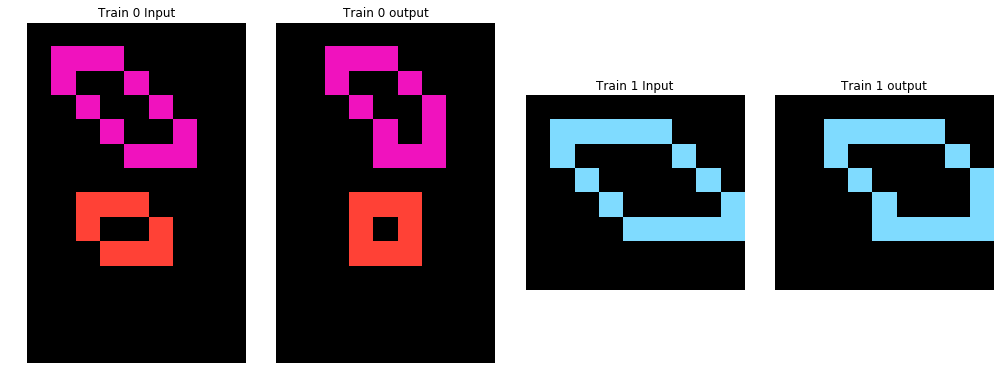

[[[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {8, 7}, {1, 2, 3, 4})], [('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [3], (3, {3, 4, 5}, {2})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg')]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('nonbg0', 'nonbg0'), ('nonbg0', 'bg')]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {8, 7}, {1, 2, 3, 4})], [('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [3], (3, {3, 4, 5}, {2})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg')]])
8


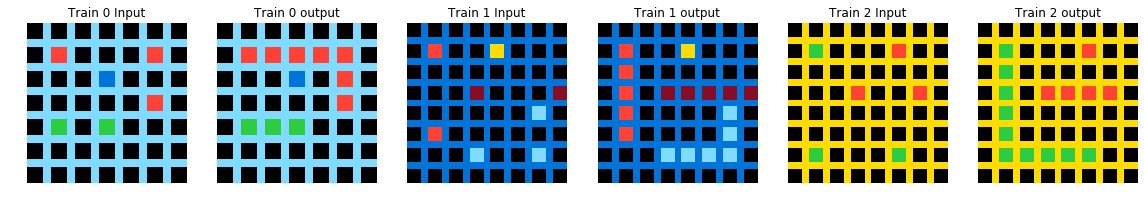

[[[('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg0pr')], [('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg1')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1'), [2], (2, {3, 4, 6, 7}, {12, 13})]], [[('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg0pr')], [('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg1')], [('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg2')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1'), [3], (3, {3, 4}, {12, 13, 15, 16, 18, 19})], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg2'), [2, 3], (2, {6, 7, 9, 10, 12, 13}, {16, 18, 19, 15}), (3, {3, 4}, {12, 13, 15, 16, 18, 19})], [('nonbg-1pr', 'nonbg1'), ('nonbg-1pr', 'nonbg2'), [2], (2, {9, 10}, {16, 18, 19, 15})]], [[('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg0pr')], [('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg1')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1')]]]
test_consistency: (False, [[('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg0pr')], [('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr',

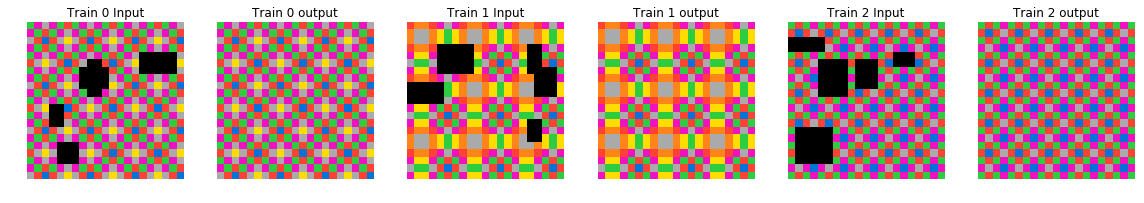

[[[('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1pr')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg2pr'), [2, 3], (2, {8, 17, 5}, {4, 6, 7, 9, 12, 13, 16, 18}), (3, {8, 17, 5}, {3, 4, 6, 7, 9, 10, 16, 18})], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg3pr')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg4pr'), [2, 3], (2, {8, 17, 5}, {4, 6, 7, 12, 13}), (3, {8, 17, 5}, {3, 4, 7, 9, 10, 15, 19})], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg5'), [7], (7, {1, 2}, {3})], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg2pr')], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg3pr')], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg4pr')], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg5')], [('nonbg-1pr', 'nonbg2pr'), ('nonbg-1pr', 'nonbg3pr')], [('nonbg-1pr', 'nonbg2pr'), ('nonbg-1pr', 'nonbg4pr')], [('nonbg-1pr', 'nonbg2pr'), ('nonbg-1pr', 'nonbg5'), [2, 3, 7], (2, {4, 6, 7, 9, 12, 13, 16, 18}, {5}), (3, {3, 4, 6, 7, 9, 10, 16, 18}, {8}), (7, {1, 4}, {3})], [('nonbg-1pr'

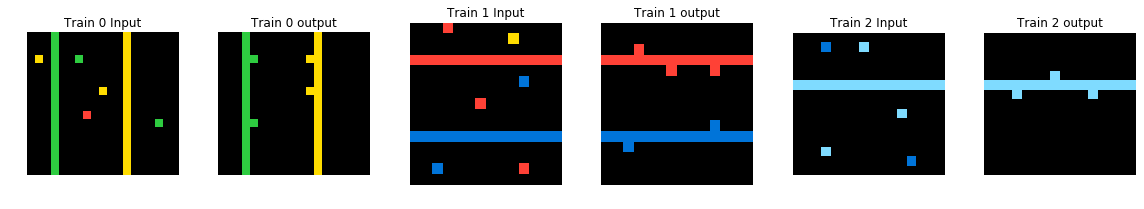

[[[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [3], (3, {4}, {11})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [3, 6, 7], (3, {3}, {16, 6}), (6, {13}, {14, 7}), (7, {2}, {1})], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [3, 6, 7], (3, {12}, {1, 9}), (6, {14}, {13, 7}), (7, {2}, {1})]], [[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {9, 11}, {2, 4})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [2, 7], (2, {10}, {13, 5}), (7, {2}, {1})], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [2, 7], (2, {3}, {0, 13, 7}), (7, {2}, {1})]], [[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [2, 6, 7], (2, {5}, {8, 1, 12}), (6, {15}, {11, 12}), (7, {2}, {1})]]]
test_consistency: (False, [[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg',

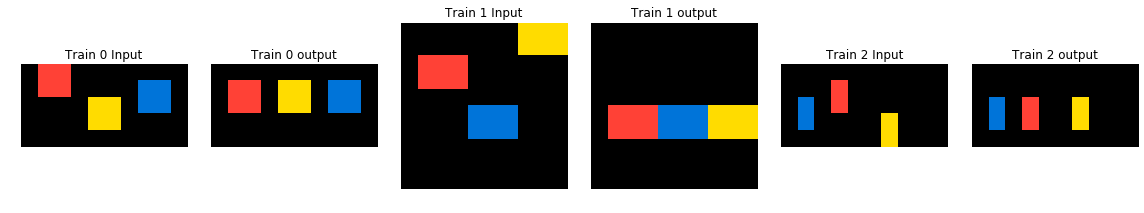

[[[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [2, 3], (2, {2}, {1}), (3, {1, 2}, {4, 5})], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [2], (2, {1}, {0})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'bg'), [2], (2, {2}, {3})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [3], (3, {1, 2, 3}, {8, 9, 7})]], [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [2, 3], (2, {3}, {2}), (3, {3}, {6})], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [2], (2, {2}, {1})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'bg'), [2], (2, {3}, {4})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [2, 3], (2, {2}, {1}), (3, {1, 2}, {4, 5})], [('nonbg0pr', 'n

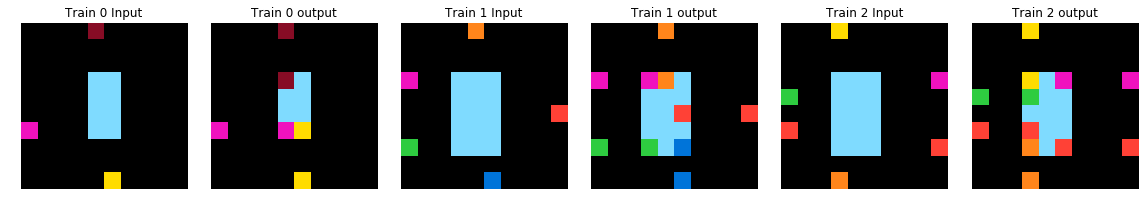

[[[('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg1pr'), [2], (2, {6}, {3, 4, 5})], [('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg2'), [3], (3, {4}, {5})], [('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg3'), [2], (2, {6}, {3})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2'), [2], (2, {3, 4, 5}, {6})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg3')], [('nonbg1pr', 'nonbg2'), ('nonbg1pr', 'nonbg3'), [2, 3], (2, {6}, {3}), (3, {5}, {4})]], [[('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg1pr')], [('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg2'), [2, 3], (2, {3}, {7}), (3, {3}, {5})], [('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg3'), [2, 3], (2, {3}, {5}), (3, {3}, {5})], [('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg4'), [2], (2, {3}, {7})], [('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg5'), [3], (3, {3}, {4})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg3')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg4')], [('nonbg1pr', 'nonbg

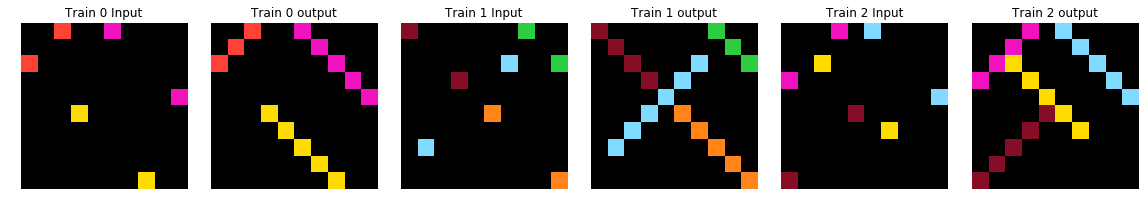

[[[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 3], (2, {1}, {8, 6, 7}), (3, {1}, {4, 5, 6})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [3], (3, {1}, {8, 6, 7})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {8, 6, 7}, {1, 2, 3})]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'bg'), ('bg', 'nonbg3')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {1}, {8, 6, 7})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [2, 3], (2, {1}, {3, 4, 5, 6}), (3, {8}, {2, 3, 4, 5})], [('bg', 'nonbg0'), ('bg', 'nonbg3'), [3], (3, {8}, {1, 2})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [3], (3, {8, 6, 7}, {2, 3, 4, 5})], [('bg', 'nonbg1'), ('bg', 'nonbg3'), [2, 3], (2, {8, 6, 7}, {1, 2}), (3, {8, 6, 7}, {1, 2})], [('bg', 'nonbg2'), ('bg', 'nonbg3'), [2], (2, {3, 4, 5, 6}, {1, 2})]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'b

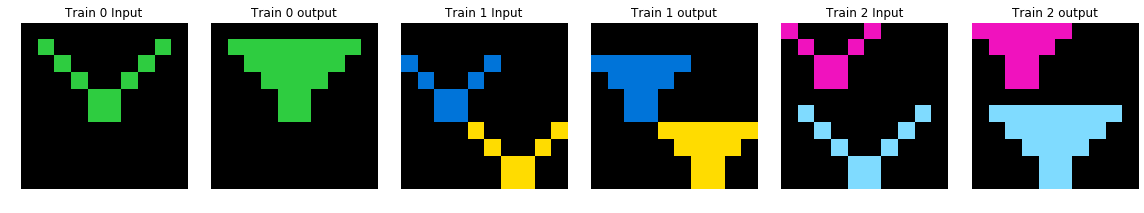

[[[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 3], (2, {2, 3}, {6, 7}), (3, {1, 2, 3, 4}, {8, 5, 6, 7})]], [[('bg', 'bg'), ('bg', 'nonbg0'), [6], (6, {15}, {2})], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 6], (2, {0, 1}, {5, 6, 7}), (6, {2}, {15})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 3], (2, {2, 3}, {6, 7}), (3, {1, 2, 3, 4}, {8, 5, 6, 7})]])
44


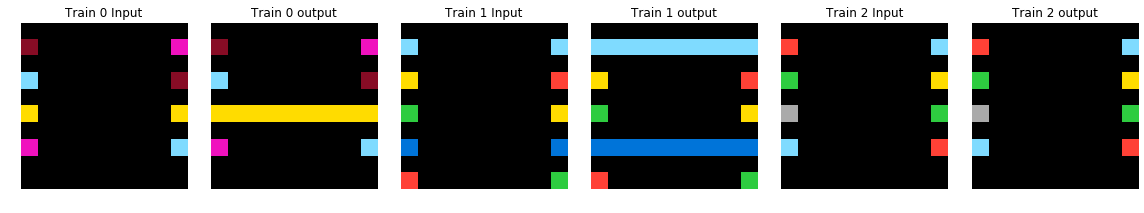

[[[('bg', 'bg'), ('bg', 'nonbg0pr'), [2], (2, {0, 1, 2, 3, 4, 6, 7, 8, 9}, {5})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [2], (2, {0, 2, 3, 4, 5, 6, 8, 9}, {1})], [('bg', 'bg'), ('bg', 'nonbg1'), [2], (2, {0, 2, 3, 4, 5, 6, 8, 9}, {7})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [2], (2, {1}, {7})]], [[('bg', 'bg', 'direct')]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0pr'), [2], (2, {0, 2, 3, 4, 5, 6, 8, 9}, {1})], [('bg', 'bg'), ('bg', 'nonbg1'), [2], (2, {0, 2, 3, 4, 5, 6, 8, 9}, {7})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [2], (2, {1}, {7})]])
52


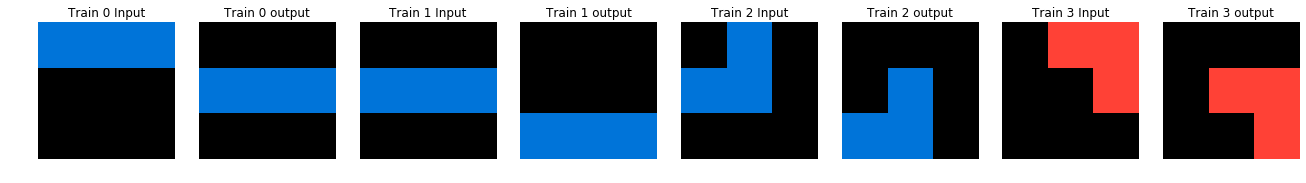

[[[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0'), [2, 7], (2, {2}, {1}), (7, {1}, {2})]], [[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0'), [2, 6], (2, {0}, {2}), (6, {11}, {12})]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('nonbg0', 'nonbg0'), ('nonbg0', 'bg')]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [2], (2, {1}, {0})]]]
test_consistency: (False, [[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0'), [2, 7], (2, {2}, {1}), (7, {1}, {2})]])
68


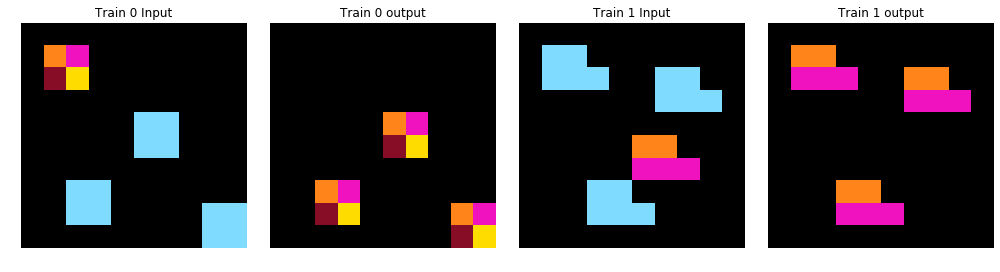

[[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('nonbg3', 'bg', 'direct')], [('nonbg4', 'bg', 'direct')], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg1pr'), [3], (3, {9, 3, 6}, {8, 2, 5})], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg3')], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg4'), [3], (3, {9, 3, 6}, {8, 2, 5})], [('nonbg2pr', 'nonbg1pr'), ('nonbg2pr', 'nonbg3'), [3], (3, {8, 2, 5}, {9, 3, 6})], [('nonbg2pr', 'nonbg1pr'), ('nonbg2pr', 'nonbg4')], [('nonbg2pr', 'nonbg3'), ('nonbg2pr', 'nonbg4'), [3], (3, {9, 3, 6}, {8, 2, 5})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg1pr')]]]
test_consistency: (False, [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('nonbg3', 'bg', 'direct')], [('nonbg4', 'bg', 'direct')], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg1pr'), [3], (3, {9, 3, 6}, {8, 2, 5})], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg3')], [('nonbg2pr', 'nonbg0pr'

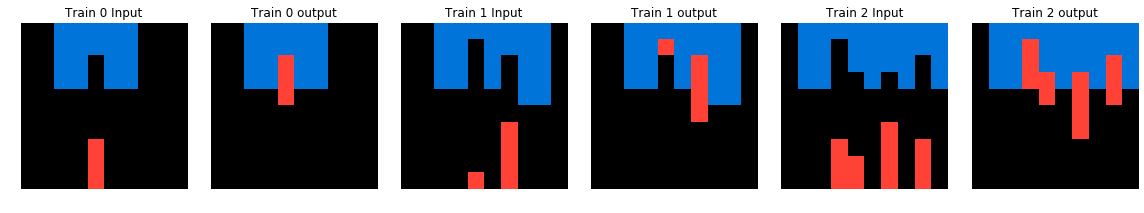

[[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')]], [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [2], (2, {6}, {8, 9, 7})]]]
test_consistency: (False, [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')]])
81


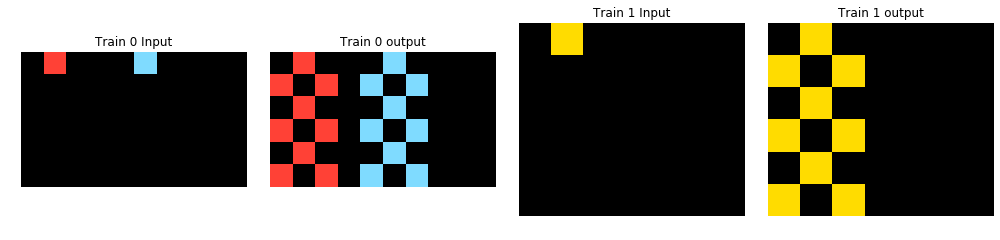

[[[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [3], (3, {0, 1, 2}, {4, 5, 6})]], [[('bg', 'bg'), ('bg', 'nonbg0')]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [3], (3, {0, 1, 2}, {4, 5, 6})]])
88


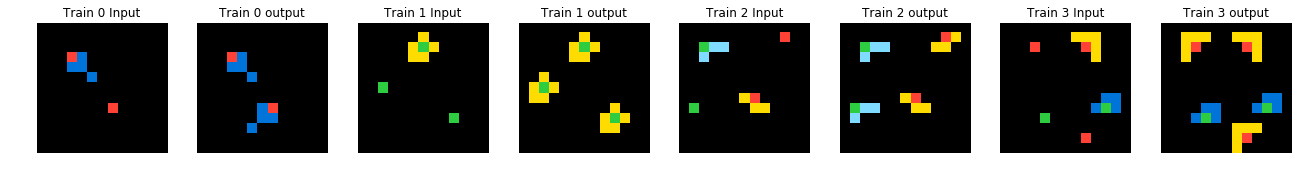

[[[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 3], (2, {1, 2}, {8, 9}), (3, {9, 10, 11}, {1, 2, 3})]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {8, 9}, {1, 2, 3, 10, 11, 12})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 3], (2, {1, 2}, {8, 9}), (3, {9, 10, 11}, {1, 2, 3})]])
97


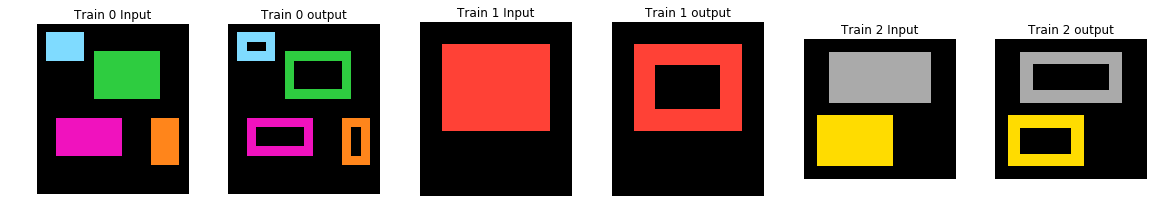

[[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]]]
test_consistency: (False, [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]])
98


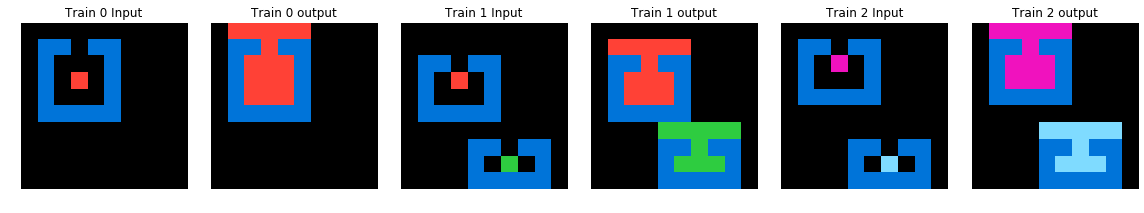

[[[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {1, 2, 3, 4}, {8, 6, 7})]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {0, 1, 2, 3}, {8, 6, 7})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {1, 2, 3, 4}, {8, 6, 7})]])
101


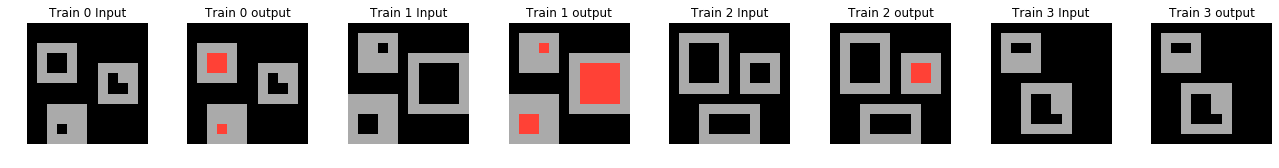

[[[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg', 'direct')]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')]])
109


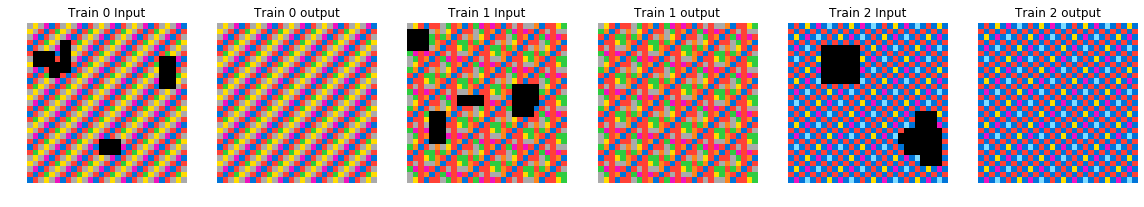

[[[('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1pr')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg2pr')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg3pr')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg4')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg5')], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg2pr')], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg3pr'), [2], (2, {3, 4, 5, 7, 9, 10, 11, 21, 22, 23}, {8, 6})], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg4')], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg5')], [('nonbg-1pr', 'nonbg2pr'), ('nonbg-1pr', 'nonbg3pr')], [('nonbg-1pr', 'nonbg2pr'), ('nonbg-1pr', 'nonbg4')], [('nonbg-1pr', 'nonbg2pr'), ('nonbg-1pr', 'nonbg5')], [('nonbg-1pr', 'nonbg3pr'), ('nonbg-1pr', 'nonbg4'), [2], (2, {8, 6}, {5, 7, 11, 21, 23})], [('nonbg-1pr', 'nonbg3pr'), ('nonbg-1pr', 'nonbg5')], [('nonbg-1pr', 'nonbg4'), ('nonbg-1pr', 'nonbg5')]], [[('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1pr')], [('nonbg-1pr', 'nonbg0pr'),

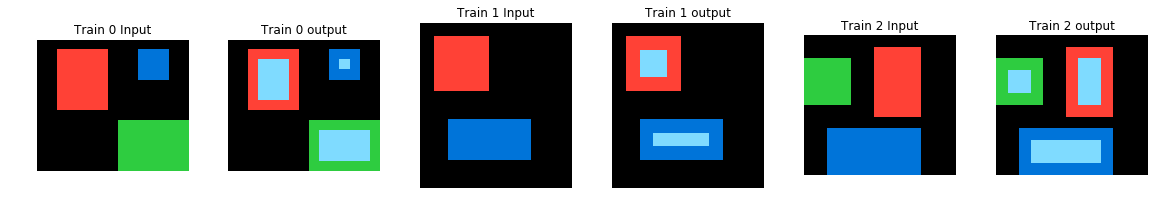

[[[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {8, 3, 4, 15}, {0})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {1, 15}, {0})]]]
test_consistency: (False, [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {8, 3, 4, 15}, {0})]])
131


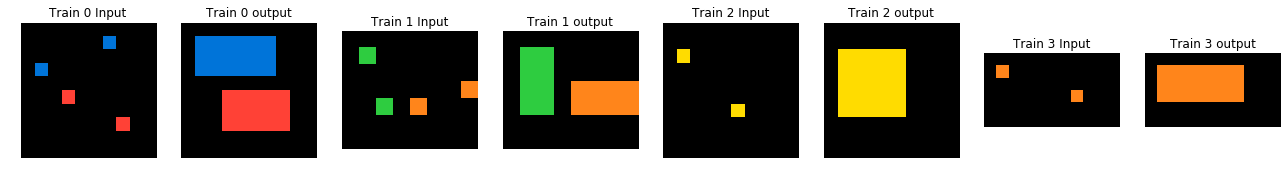

[[[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {1, 2, 3}, {5, 6, 7})]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [3], (3, {1, 2}, {4, 5, 6, 7})]], [[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0')]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {1, 2, 3}, {5, 6, 7})]])
132


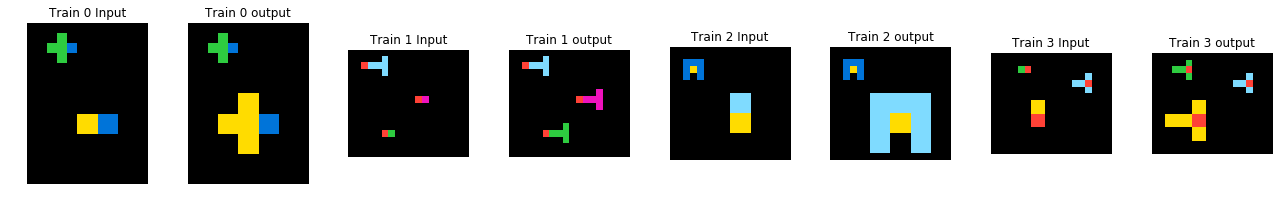

[[[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 3], (2, {11, 12, 13}, {8, 6, 7}), (3, {8, 7}, {12, 13})]], [[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {1, 2, 3}, {9, 10, 11, 12})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 3], (2, {11, 12, 13}, {8, 6, 7}), (3, {8, 7}, {12, 13})]])
160


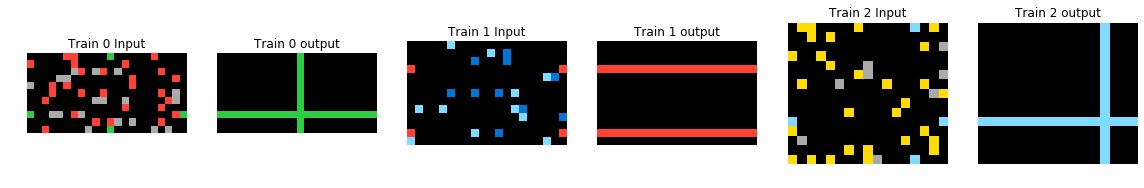

[[[('bg', 'bg'), ('bg', 'nonbg0')], [('nonbg1', 'bg'), ('nonbg1', 'nonbg0'), [2], (2, {2, 3, 4, 5, 6, 9, 10}, {8})], [('nonbg2', 'bg'), ('nonbg2', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0'), [2], (2, {0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 12}, {11, 3})], [('nonbg1', 'bg'), ('nonbg1', 'nonbg0'), [2], (2, {1, 2, 4, 6, 8, 9}, {11})], [('nonbg2', 'bg'), ('nonbg2', 'nonbg0'), [2, 3], (2, {0, 1, 4, 6, 8, 9, 12}, {11}), (3, {0, 1, 4, 5, 10, 13, 14, 17}, {8})]], [[('nonbg1', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('nonbg1', 'bg'), ('nonbg1', 'nonbg0'), [2], (2, {2, 3, 4, 5, 6, 9, 10}, {8})], [('nonbg2', 'bg'), ('nonbg2', 'nonbg0')]])
166


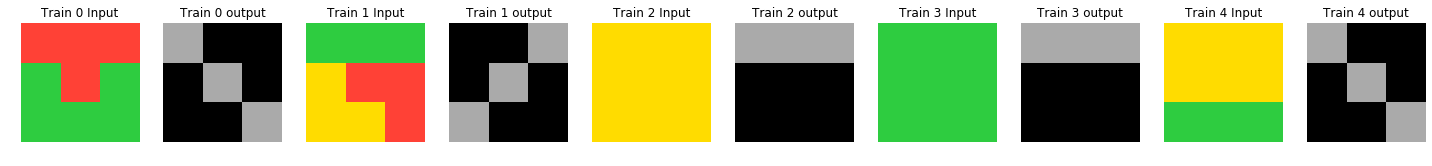

[[[('nonbg1', 'nonbg-1pr'), ('nonbg1', 'nonbg0pr')], [('nonbg2', 'nonbg-1pr'), ('nonbg2', 'nonbg0pr')]], [[('nonbg1', 'nonbg-1pr'), ('nonbg1', 'nonbg0pr'), [3], (3, {2}, {1})], [('nonbg2', 'nonbg-1pr'), ('nonbg2', 'nonbg0pr'), [3, 7], (3, {0, 1}, {2}), (7, {3}, {2})], [('nonbg3', 'nonbg-1pr'), ('nonbg3', 'nonbg0pr'), [6], (6, {8, 12}, {9})]], [[('nonbg1', 'nonbg-1pr'), ('nonbg1', 'nonbg0pr'), [2], (2, {1, 2}, {0})]], [[('nonbg1', 'nonbg-1pr'), ('nonbg1', 'nonbg0pr'), [2], (2, {1, 2}, {0})]], [[('nonbg1', 'nonbg-1pr'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 1}, {2})], [('nonbg2', 'nonbg-1pr'), ('nonbg2', 'nonbg0pr')]]]
test_consistency: (False, [[('nonbg1', 'nonbg-1pr'), ('nonbg1', 'nonbg0pr'), [3], (3, {2}, {1})], [('nonbg2', 'nonbg-1pr'), ('nonbg2', 'nonbg0pr'), [3, 7], (3, {0, 1}, {2}), (7, {3}, {2})], [('nonbg3', 'nonbg-1pr'), ('nonbg3', 'nonbg0pr'), [6], (6, {8, 12}, {9})]])
172


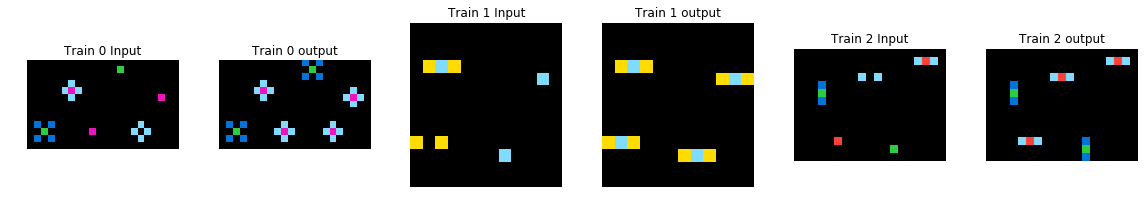

[[[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1'), [6], (6, {15}, {0})], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [3, 6], (3, {8, 9, 10, 18, 19, 20}, {16}), (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg2'), [2, 3], (2, {4, 5, 6, 9, 10, 11}, {0, 2}), (3, {8, 9, 10, 18, 19, 20}, {12, 14})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2, 3, 6], (2, {10}, {0, 2}), (3, {16}, {12, 14}), (6, {0}, {15})]], [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [2, 3], (2, {9}, {10, 4}), (3, {1}, {8, 9, 11, 6})]], [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [3], (3, {4, 6}, {12})], [('bg', 'nonbg0pr'), ('bg', 'nonbg2'), [2, 3], (2, {11}, {3}), (3, {4, 6}, {9})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2, 3], (2, {11, 13}, {3}), (3, {12}, {9})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg',

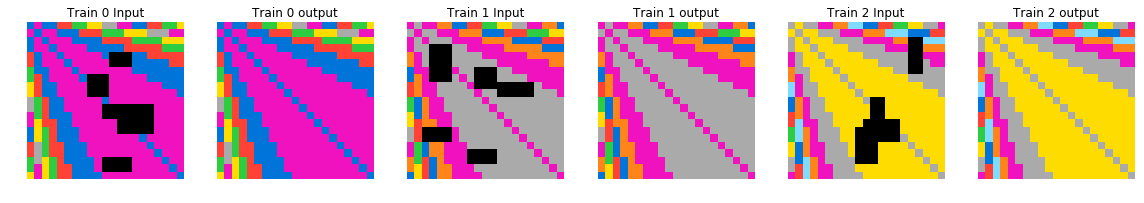

[[[('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1pr')]], [[('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1pr'), [2, 3], (2, {14, 15}, {3, 4, 5, 6, 7, 8, 9, 17, 18}), (3, {2}, {3, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16})], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg2pr'), [3], (3, {2}, {8, 3, 4, 5})], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg3'), [3], (3, {2}, {3})], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg2pr')], [('nonbg-1pr', 'nonbg1pr'), ('nonbg-1pr', 'nonbg3'), [2], (2, {3, 4, 5, 6, 7, 8, 9, 17, 18}, {14, 15})], [('nonbg-1pr', 'nonbg2pr'), ('nonbg-1pr', 'nonbg3')]], [[('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg1pr')], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg2pr'), [2, 3], (2, {10, 11, 12, 13, 14, 15, 16, 17, 18}, {3, 4}), (3, {9, 10, 11, 12, 13, 14}, {16, 17})], [('nonbg-1pr', 'nonbg0pr'), ('nonbg-1pr', 'nonbg3'), [2, 3, 7], (2, {10, 11, 12, 13, 14, 15, 16, 17, 18}, {2}), (3, {9, 10, 11, 12, 13, 14}, {16, 17}), (7, {1, 2, 3}, {4, 5})], [('nonbg-1p

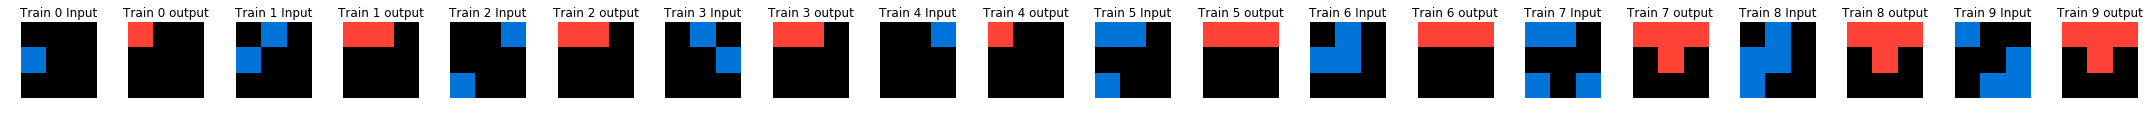

[[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr')]], [[('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {5})], [('nonbg0pr', 'bg'), ('nonbg0pr', 'nonbg1pr'), [2, 3], (2, {1}, {0}), (3, {0}, {1})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [2], (2, {1, 2}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg1pr')], [('nonbg0pr', 'bg'), ('nonbg0pr', 'nonbg1pr'), [2, 3], (2, {1}, {0}), (3, {2}, {1})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr')]], [[('bg', 'bg'), ('bg', 'nonbg1pr'), [2], (2, {1, 2}, {0})], [('nonbg0pr', 'bg'), ('nonbg0pr', 'nonbg1pr'), [2, 7], (2, {2}, {0}), (7, {1}, {2})]], [[('bg', 'bg'), ('bg', 'nonbg1pr'), [2], (2, {1, 2}, {0})], [('nonbg0pr', 'bg'), ('nonbg0pr', 'nonbg1pr'), [2], (2, {1}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg1pr')], [('nonbg0pr', 'bg'), ('nonbg0pr', 'nonbg1pr'), [2, 7], (2, {2}, {0}), (7, {1}, {2})]], [[('bg', 'bg'), ('bg', 'nonbg1pr'), [2], (2, {1, 2}, {0})], [('nonbg0pr', 'bg'), ('nonbg0pr', 'no

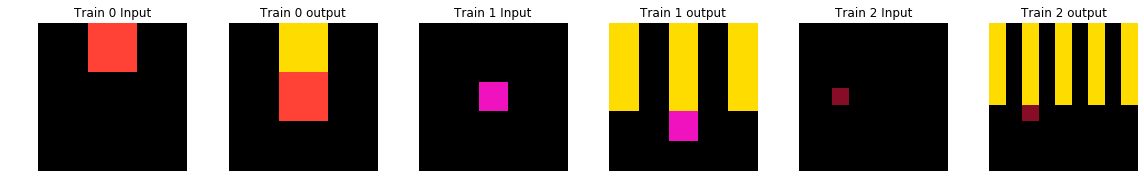

[[[('nonbg1', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')]], [[('nonbg1', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [2], (2, {0, 1, 2}, {3})]], [[('nonbg1', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [2], (2, {0, 1, 2, 3, 4}, {5})]]]
test_consistency: (False, [[('nonbg1', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [2], (2, {0, 1, 2}, {3})]])
201


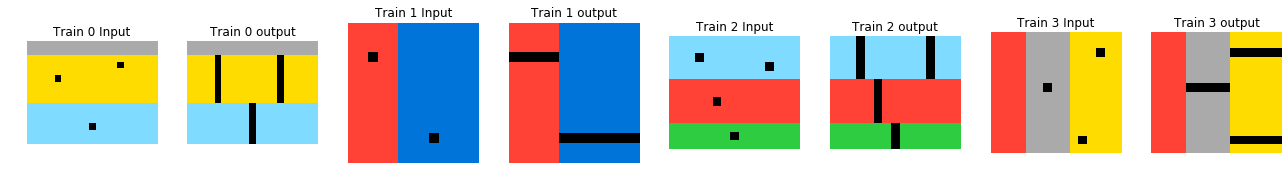

[[[('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1pr'), [3], (3, {0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18}, {9})], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg-1pr'), [3], (3, {0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18}, {4, 13})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1pr'), [2], (2, {0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13}, {3})], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg-1pr'), [2], (2, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13}, {11})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1pr'), [3], (3, {0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14}, {7})], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg-1pr'), [3], (3, {0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14}, {11, 3})], [('nonbg2', 'nonbg2'), ('nonbg2', 'nonbg-1pr'), [3], (3, {0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14}, {5})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1pr'), [2], (2, {0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13}, {6})], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg-1pr'), [2], (2, {0, 1, 3, 4

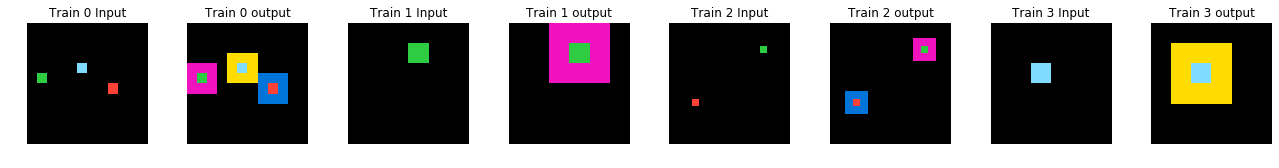

[[[('bg', 'bg'), ('bg', 'nonbg0'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg2'), [7], (7, {1}, {2})], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [3], (3, {8, 9, 7}, {4, 5, 6})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [3], (3, {8, 9, 7}, {0, 1, 2})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [3], (3, {4, 5, 6}, {0, 1, 2})]], [[('bg', 'bg'), ('bg', 'nonbg0'), [7], (7, {1}, {2})]], [[('bg', 'bg'), ('bg', 'nonbg0'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1'), [7], (7, {1}, {2})], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 3], (2, {9, 10, 11}, {2, 3, 4}), (3, {2, 3, 4}, {11, 12, 13})]], [[('bg', 'bg'), ('bg', 'nonbg0'), [7], (7, {1}, {2})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg2'), [7], (7, {1}, {2})], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [3], (3, {8, 9, 7}, {4, 5, 6})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [3

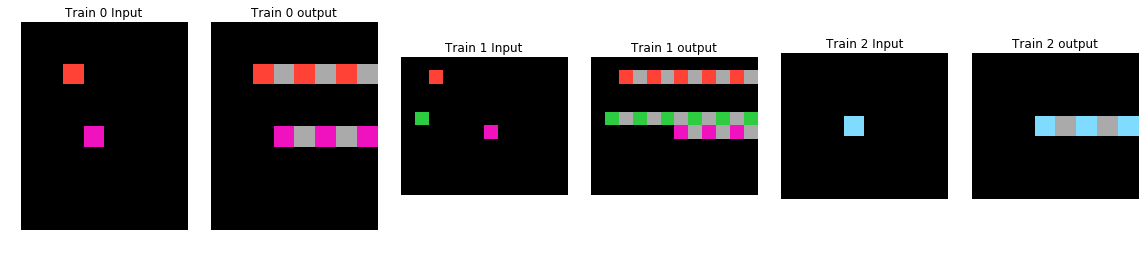

[[[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1')], [('bg', 'nonbg0pr'), ('bg', 'nonbg2')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2, 3], (2, {2}, {5}), (3, {4, 6}, {5, 7})]], [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'bg'), ('bg', 'nonbg3')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1')], [('bg', 'nonbg0pr'), ('bg', 'nonbg2')], [('bg', 'nonbg0pr'), ('bg', 'nonbg3')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2, 3], (2, {1}, {4}), (3, {8, 10, 4, 6}, {3, 5, 7, 9, 11})], [('bg', 'nonbg1'), ('bg', 'nonbg3'), [2], (2, {1}, {5})], [('bg', 'nonbg2'), ('bg', 'nonbg3'), [2, 3], (2, {4}, {5}), (3, {3, 5, 7, 9, 11}, {8, 10})]], [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [3], (3, {4, 6}, {5, 7})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg'

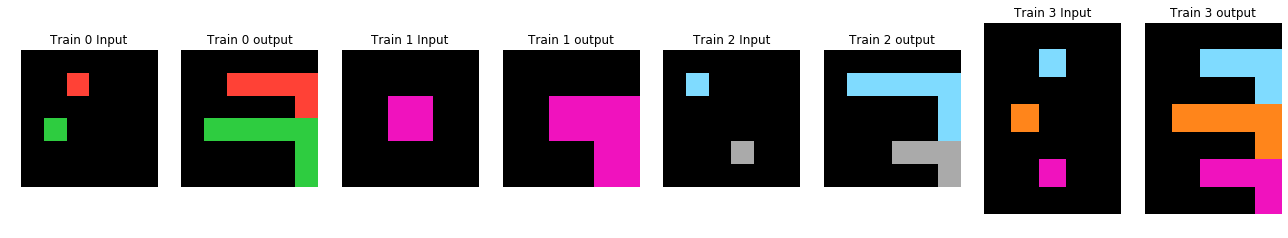

[[[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {1, 2}, {3, 4, 5})]], [[('bg', 'bg'), ('bg', 'nonbg0')]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {4, 5}, {1, 2, 3})]], [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {5, 6}, {3, 4})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [2], (2, {5, 6}, {1, 2})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {3, 4}, {1, 2})]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {5, 6}, {3, 4})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [2], (2, {5, 6}, {1, 2})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {3, 4}, {1, 2})]])
239


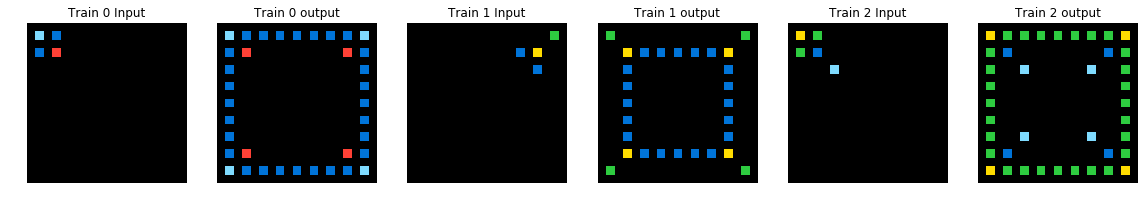

[[[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1')], [('bg', 'nonbg0pr'), ('bg', 'nonbg2')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2, 3], (2, {3, 15}, {1, 17}), (3, {3, 15}, {17, 1})]], [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [2, 3], (2, {3, 5, 7, 9, 11, 13, 15}, {1, 17}), (3, {3, 5, 7, 9, 11, 13, 15}, {1, 17})], [('bg', 'nonbg0pr'), ('bg', 'nonbg2')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2, 3], (2, {1, 17}, {3, 15}), (3, {1, 17}, {3, 15})]], [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'bg'), ('bg', 'nonbg3')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1'), [2, 3], (2, {3, 15}, {1, 17}), (3, {3, 15}, {17, 1})], [('bg', 'nonbg0pr'), ('bg', 'nonbg2'), [2, 3], (2, {3, 15}, {13, 5}), (3, {3, 15}, {5, 13})], [('bg', 'nonbg0pr'), ('bg', 

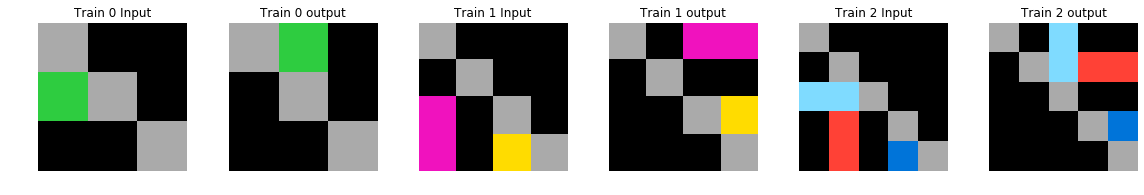

[[[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')]], [[('nonbg0', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 7], (2, {2}, {0}), (7, {3}, {1, 2})]], [[('nonbg0', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 7], (2, {3}, {1}), (7, {3}, {1, 2})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [2, 3], (2, {3}, {0, 1}), (3, {4}, {2})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [3], (3, {3, 4}, {2})]]]
test_consistency: (False, [[('nonbg0', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [2, 7], (2, {3}, {1}), (7, {3}, {1, 2})], [('bg', 'nonb

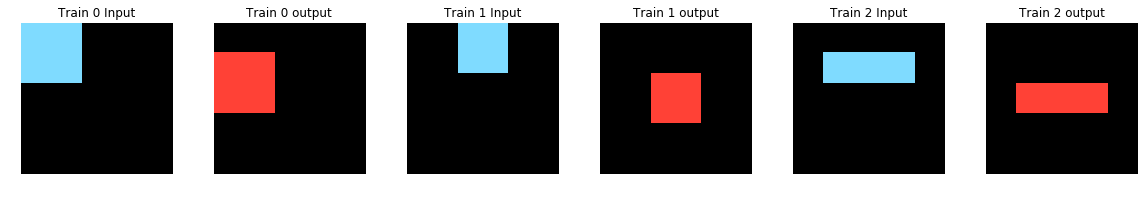

[[[('bg', 'bg'), ('bg', 'nonbg0pr')], [('nonbg1pr', 'bg'), ('nonbg1pr', 'nonbg0pr'), [2], (2, {0}, {1})]], [[('nonbg1pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')]], [[('nonbg1pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_consistency: (False, [[('bg', 'bg'), ('bg', 'nonbg0pr')], [('nonbg1pr', 'bg'), ('nonbg1pr', 'nonbg0pr'), [2], (2, {0}, {1})]])
261


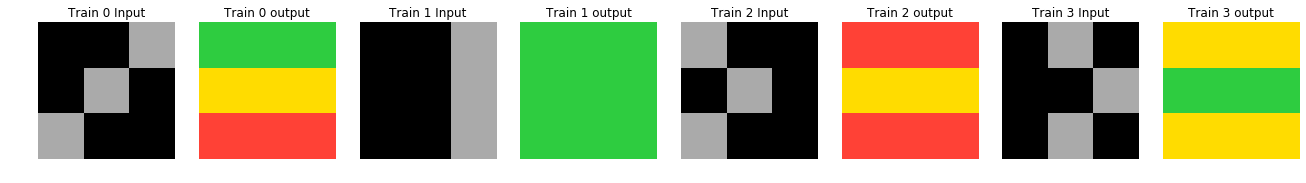

[[[('bg', 'nonbg1'), ('bg', 'nonbg2'), [2, 6], (2, {2}, {0}), (6, {8}, {5})], [('bg', 'nonbg1'), ('bg', 'nonbg3'), [2], (2, {2}, {1})], [('bg', 'nonbg2'), ('bg', 'nonbg3'), [2], (2, {0}, {1})], [('nonbg0pr', 'nonbg1'), ('nonbg0pr', 'nonbg2'), [2, 3], (2, {2}, {0}), (3, {0}, {2})], [('nonbg0pr', 'nonbg1'), ('nonbg0pr', 'nonbg3'), [2, 3], (2, {2}, {1}), (3, {0}, {1})], [('nonbg0pr', 'nonbg2'), ('nonbg0pr', 'nonbg3'), [2, 3], (2, {0}, {1}), (3, {2}, {1})]], [[('bg', 'nonbg1', 'direct')], [('nonbg0pr', 'nonbg1', 'direct')]], [[('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {0, 2}, {1})], [('nonbg0pr', 'nonbg1'), ('nonbg0pr', 'nonbg2'), [2, 3], (2, {0, 2}, {1}), (3, {0}, {1})]], [[('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {1}, {0, 2})], [('nonbg0pr', 'nonbg1'), ('nonbg0pr', 'nonbg2'), [2, 3], (2, {1}, {0, 2}), (3, {2}, {1})]]]
test_consistency: (False, [[('bg', 'nonbg1'), ('bg', 'nonbg2'), [2, 6], (2, {2}, {0}), (6, {8}, {5})], [('bg', 'nonbg1'), ('bg', 'nonbg3'), [2], (2, {2}, {1})], [('b

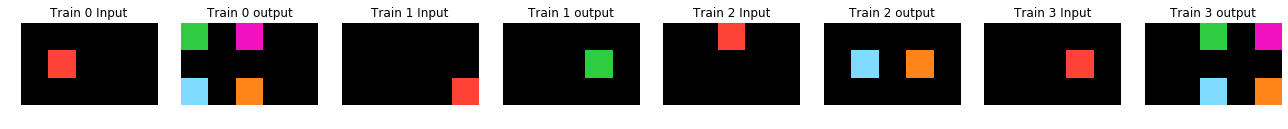

[[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'bg'), ('bg', 'nonbg3')], [('bg', 'bg'), ('bg', 'nonbg4')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [3], (3, {0}, {2})], [('bg', 'nonbg1'), ('bg', 'nonbg3'), [2, 3], (2, {0}, {2}), (3, {0}, {2})], [('bg', 'nonbg1'), ('bg', 'nonbg4'), [2], (2, {0}, {2})], [('bg', 'nonbg2'), ('bg', 'nonbg3'), [2], (2, {0}, {2})], [('bg', 'nonbg2'), ('bg', 'nonbg4'), [2, 3], (2, {0}, {2}), (3, {2}, {0})], [('bg', 'nonbg3'), ('bg', 'nonbg4'), [3], (3, {2}, {0})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [3], (3, {3}, {1})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'bg'), ('bg', 'nonbg2')], [('bg', 'bg'), ('bg', 'nonbg3')], [('bg', 'bg'), ('bg', 'nonbg4')], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [3], (3, {2

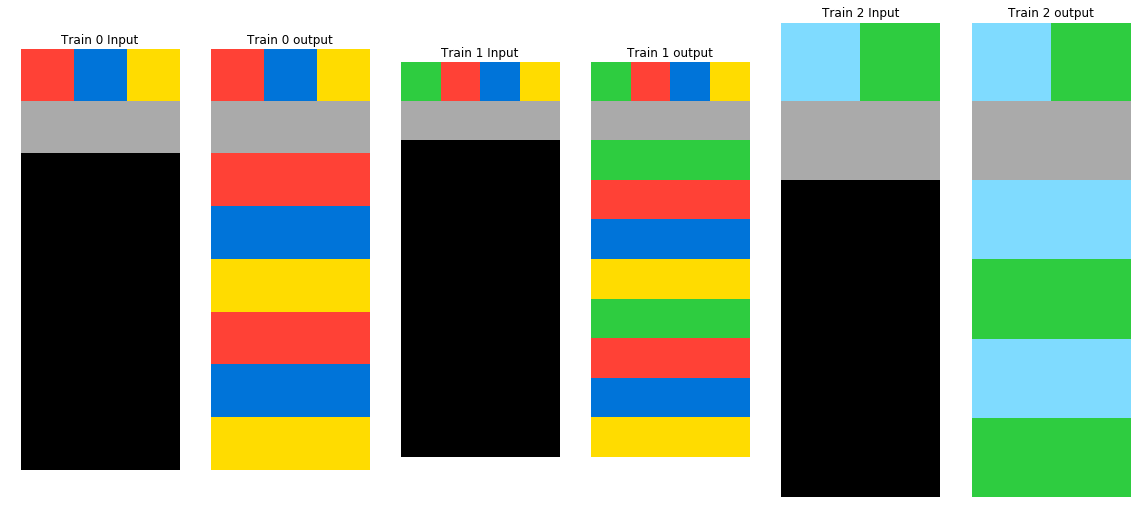

[[[('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {3, 6}, {2, 5})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [2], (2, {3, 6}, {4, 7})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {2, 5}, {4, 7})]], [[('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {8, 4}, {3, 7})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [2], (2, {8, 4}, {2, 6})], [('bg', 'nonbg0'), ('bg', 'nonbg3'), [2], (2, {8, 4}, {9, 5})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {3, 7}, {2, 6})], [('bg', 'nonbg1'), ('bg', 'nonbg3'), [2], (2, {3, 7}, {9, 5})], [('bg', 'nonbg2'), ('bg', 'nonbg3'), [2], (2, {2, 6}, {9, 5})]], [[('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {3, 5}, {2, 4})]]]
test_consistency: (False, [[('bg', 'nonbg0'), ('bg', 'nonbg1'), [2], (2, {8, 4}, {3, 7})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [2], (2, {8, 4}, {2, 6})], [('bg', 'nonbg0'), ('bg', 'nonbg3'), [2], (2, {8, 4}, {9, 5})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [2], (2, {3, 7}, {2, 6})], [('bg', 'nonbg1'), ('bg', 'nonbg3'), [2], (2, {3, 7}, {9, 5})], [('bg'

KeyboardInterrupt: 

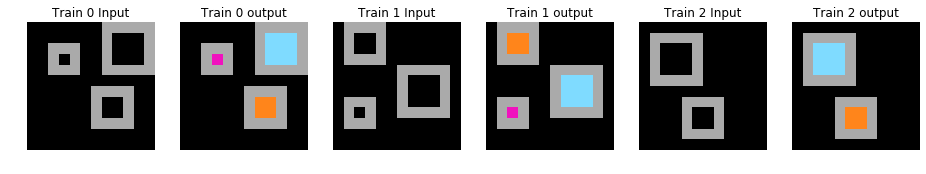

In [55]:
for n in range(400):
    this_task = today_analysis[n]
    if this_task.objective_status == 'red' and this_task.dimension_status == 'deduced' and this_task.running_objective != this_task.objective:
        print(n)
        plot_task(tt[n])
        print(this_task.running_objective)
        print('test_consistency:', test_consistency(this_task))
        print('=======')

10


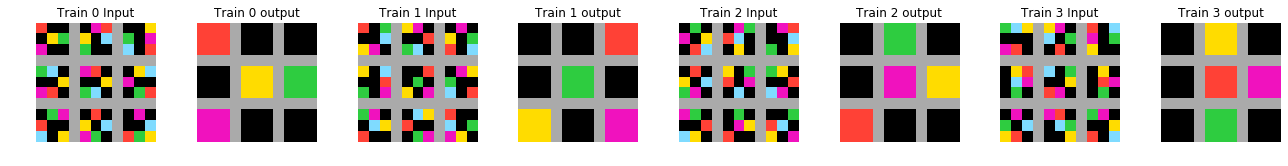

[[[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg1pr')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg3pr')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg4pr')], [('nonbg0pr', 'nonbg1pr'), ('nonbg0pr', 'nonbg2pr'), [2, 3], (2, {0, 1, 2}, {4, 5, 6}), (3, {0, 1, 2}, {8, 9, 10})], [('nonbg0pr', 'nonbg1pr'), ('nonbg0pr', 'nonbg3pr'), [2, 3], (2, {0, 1, 2}, {4, 5, 6}), (3, {0, 1, 2}, {4, 5, 6})], [('nonbg0pr', 'nonbg1pr'), ('nonbg0pr', 'nonbg4pr'), [2], (2, {0, 1, 2}, {8, 9, 10})], [('nonbg0pr', 'nonbg2pr'), ('nonbg0pr', 'nonbg3pr'), [3], (3, {8, 9, 10}, {4, 5, 6})], [('nonbg0pr', 'nonbg2pr'), ('nonbg0pr', 'nonbg4pr'), [2, 3], (2, {4, 5, 6}, {8, 9, 10}), (3, {8, 9, 10}, {0, 1, 2})], [('nonbg0pr', 'nonbg3pr'), ('nonbg0pr', 'nonbg4pr'), [2, 3], (2, {4, 5, 6}, {8, 9, 10}), (3, {4, 5, 6}, {0, 1, 2})], [('nonbg1pr', 'nonbg0pr'), ('nonbg1pr', 'nonbg1pr'), [3, 6, 7], (3, {1, 5, 6, 8, 10}, {0}), (6, {15}, {5}), (7, {3, 4}, {2})], [('nonbg1pr',

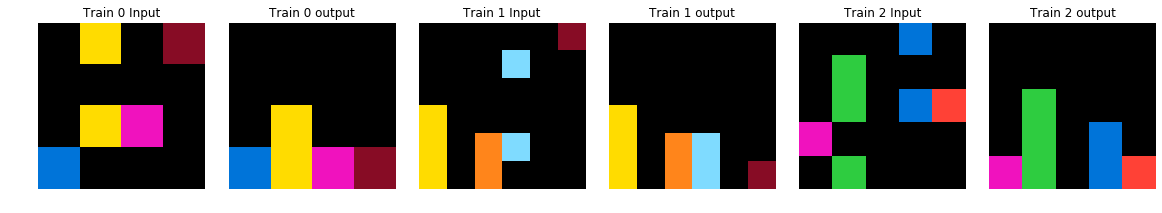

[[[('nonbg0', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0'), [2], (2, {0, 1, 2}, {3})], [('bg', 'bg'), ('bg', 'nonbg1'), [2], (2, {0, 1, 2}, {3})], [('bg', 'bg'), ('bg', 'nonbg2'), [2], (2, {0, 1, 2}, {3})], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [3, 7], (3, {2}, {3}), (7, {3}, {2})], [('bg', 'nonbg0'), ('bg', 'nonbg2'), [3, 7], (3, {2}, {1}), (7, {3}, {4})], [('bg', 'nonbg1'), ('bg', 'nonbg2'), [3, 7], (3, {3}, {1}), (7, {2}, {4})], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [2, 7], (2, {2}, {0}), (7, {3}, {1})]], [[('nonbg0', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0')], [('bg', 'bg'), ('bg', 'nonbg1')], [('bg', 'nonbg0'), ('bg', 'nonbg1'), [3, 7], (3, {5}, {3}), (7, {1}, {3})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [2, 7], (2, {4}, {1}), (7, {2}, {1})]], [[('nonbg0', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0'), [7], (7, {2, 3}, {1})], [('bg', 'bg'), ('bg', 'nonbg1'), [6], (6, {15

KeyboardInterrupt: 

In [60]:
for n in range(400):
    this_task = today_analysis[n]
    if this_task.objective_status == 'irr' and this_task.dimension_status == 'deduced' and this_task.running_objective != this_task.objective:
        print(n)
        plot_task(tt[n])
        print(this_task.running_objective)
        print('test_consistency:', test_consistency(this_task))
        print('=======')

In [73]:
this_task = today_analysis[99]

In [74]:
test_consistency(this_task)

lead_objective:  [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 4, 5], (1, {8}), (4, {14}), (5, {1})]]
[True, None, None]
[True, None, None]
test_objective:  [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 4, 5], (1, {7}), (4, {16}), (5, {1})]]
this_case_consistency:  [None, None, None]
this_case_consistency:  [True, None, None]
this_case_consistency:  [True, True, None]
this_case_consistency:  [True, True, False]
[True, False, None]
test_objective:  [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 4, 5, 6], (1, {4}), (4, {22}), (5, {1}), (6, {2})]]
this_case_consistency:  [None, None, None]
this_case_consistency:  [True, None, None]
this_case_consistency:  [True, True, None]
this_case_consistency:  [True, True, False]
[True, False, False]


(False,
 [[('bg', 'nil', 'direct')],
  [('nonbg0', 'nil', 'direct')],
  [('nonbg1', 'nonbg1', 'direct'), [1, 4, 5], (1, {8}), (4, {14}), (5, {1})]])

345
[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 6, 7], (1, {2}), (6, {0}), (7, {1})]]


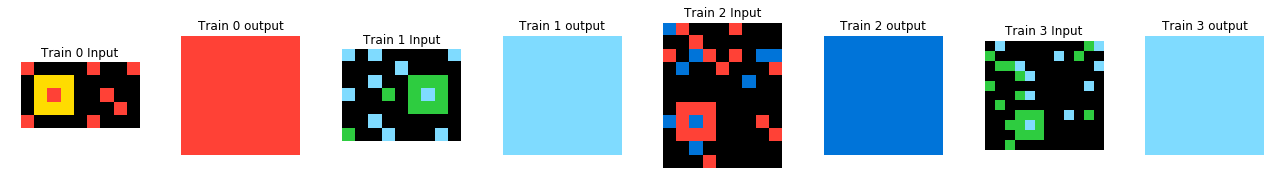

=====
48
[[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {9}), (5, {0})]]


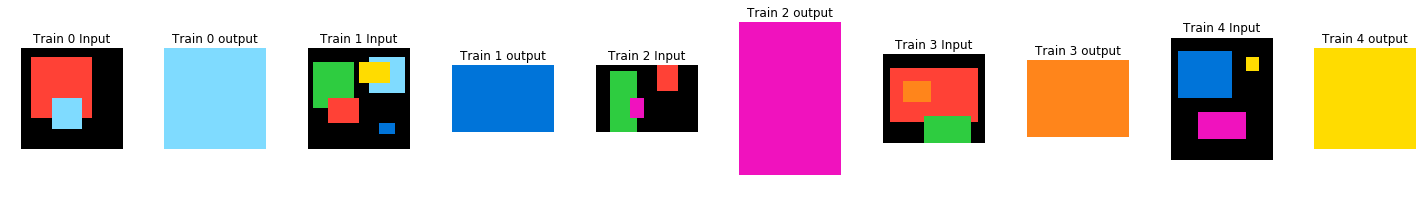

=====
66
[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]


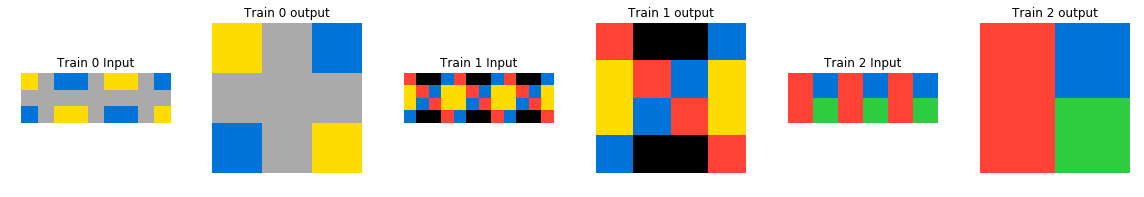

=====
105
[[('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]


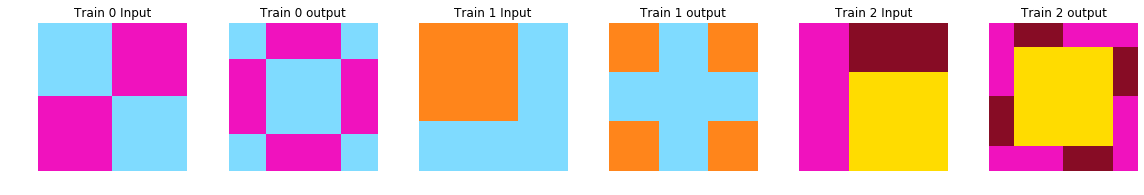

=====
129
[[('nonbg0pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]


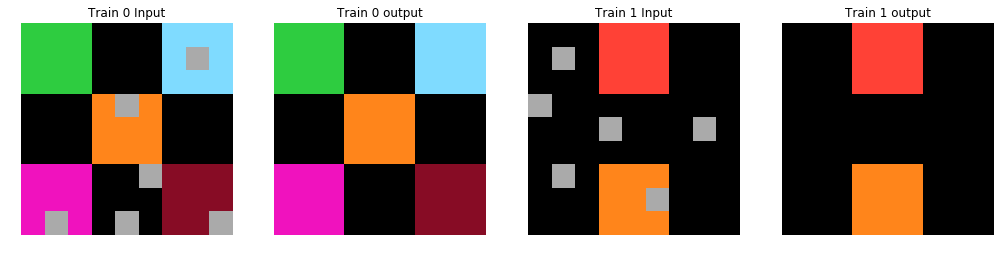

=====
151
[[('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]


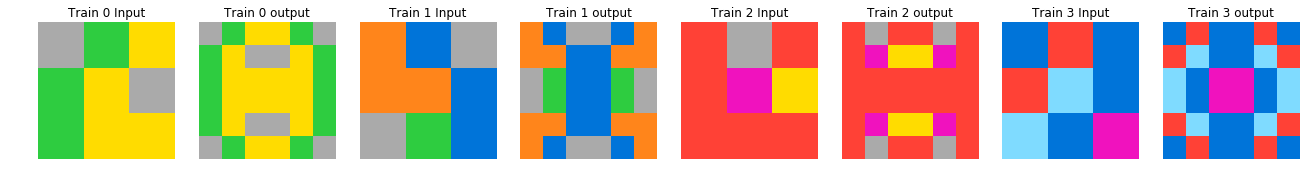

=====
217
[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]]


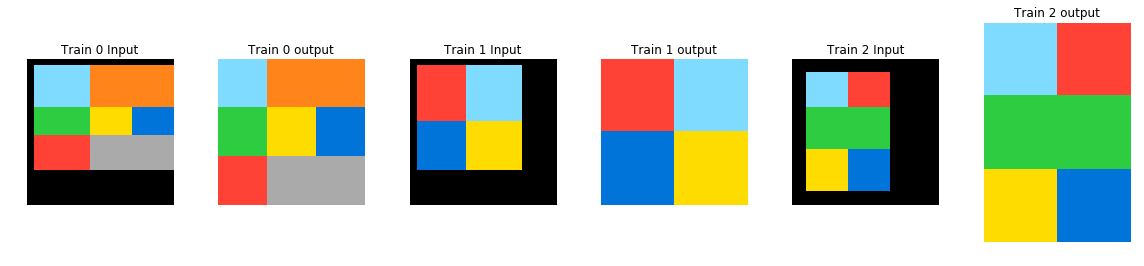

=====
290
[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg6', 'nil', 'direct')], [('nonbg5', 'nonbg5', 'direct'), [1, 4, 5], (1, {6}), (4, {10}), (5, {3})]]


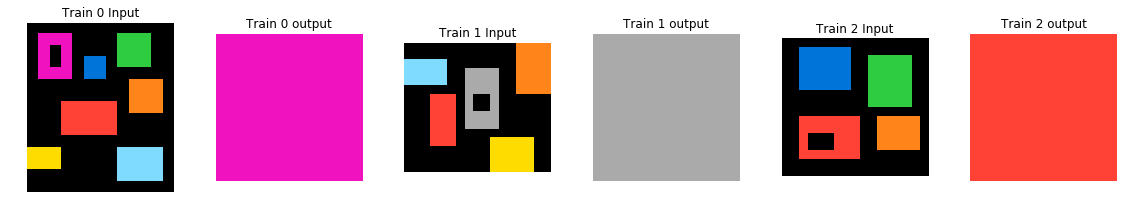

=====


In [30]:
checs = [345, 48, 66, 105, 129, 151, 217, 290]
for n in checs:
    print(n)
    print(previous_analysis[n].running_objective[0])
    plot_task(tt[n])
    print('=====')

In [31]:
previous_analysis[290].running_objective

[[[('bg', 'nil', 'direct')],
  [('nonbg0pr', 'nil', 'direct')],
  [('nonbg1pr', 'nil', 'direct')],
  [('nonbg2', 'nil', 'direct')],
  [('nonbg3', 'nil', 'direct')],
  [('nonbg4', 'nil', 'direct')],
  [('nonbg6', 'nil', 'direct')],
  [('nonbg5', 'nonbg5', 'direct'), [1, 4, 5], (1, {6}), (4, {10}), (5, {3})]],
 [[('bg', 'nil', 'direct')],
  [('nonbg0pr', 'nil', 'direct')],
  [('nonbg1pr', 'nil', 'direct')],
  [('nonbg2', 'nil', 'direct')],
  [('nonbg3', 'nil', 'direct')],
  [('nonbg4', 'nonbg4', 'direct'), [1], (1, {5})]],
 [[('bg', 'nil', 'direct')],
  [('nonbg1pr', 'nil', 'direct')],
  [('nonbg2', 'nil', 'direct')],
  [('nonbg3', 'nil', 'direct')],
  [('nonbg0pr', 'nonbg0pr', 'direct'),
   [1, 4, 5],
   (1, {2}),
   (4, {29}),
   (5, {1})]]]

In [24]:
coding_situation = {}
coding_situation[-1] = []
coding_situation[0] = []
coding_situation[1] = []


for n in range(len(previous_analysis)):
    this_task = previous_analysis[n]
    if this_task.objective_status == 'irr':
        coding_situation[-1].append(n)
    elif this_task.objective_status == 'obd':
        coding_situation[0].append(n)
    elif this_task.objective_status == 'red':
        coding_situation[1].append(n)

        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))
# -1  :  64 # irr
# 0  :  245 # obd
# 1  :  91 # red 

# Evaluation (never inspected for now)
# -1  :  0
# 0  :  92
# 1  :  308

-1  :  64
0  :  245
1  :  91


In [25]:
def screen_all(previous_analysis):
    results = deepcopy(results_dict)
    
    for task in range(len(previous_analysis)):
        #print(task)
        this_task = deepcopy(previous_analysis[task])
        current_situation, train_situation, train_screen, test_situation, test_screen = this_task.current_situation, this_task.train_situation, this_task.train_screen, this_task.test_situation, this_task.test_screen
        
        if current_situation in results_dict.keys():
            results[current_situation].append(task)
        else:
            results['unknown'].append((task, current_situation))

    for k, v in results.items():
        print(k, ' : ', len(v))
    
    return results

screening_results = screen_all(previous_analysis)

serialize(screening_results, 'assets/screening_results')

ineligible  :  380
passed_all_traininputs  :  0
passed_some_traininputs  :  0
unpassed_all_traininputs  :  0
passed_all_testinputs  :  20
passed_some_testinputs  :  0
unpassed_all_testinputs  :  0
unknown  :  0


In [26]:
all_undeduced = 0
for n in previous_analysis:
    if n.dimension_status != 'deduced':
        all_undeduced += 1
all_undeduced

# training: 310 deduces: 0.775

95

In [ ]:
initiated = 0
for n in range(len(previous_analysis)):
    for m in previous_analysis[n].apply_routine_list:
        if m[2] != 'ineligible':
            initiated += 1
            print(n)
            print(previous_analysis[n].apply_routine_list)
            plot_task(tt[n])
            print('====')

15


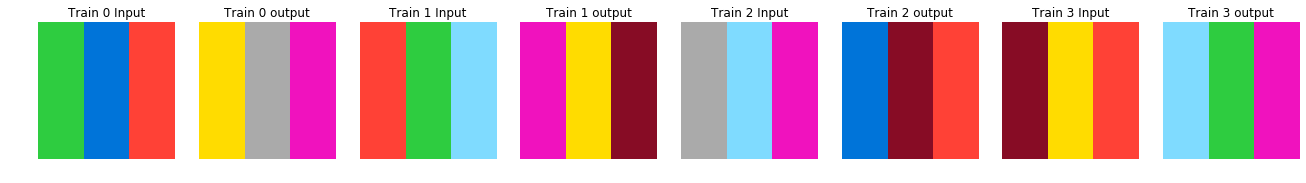

=====
86


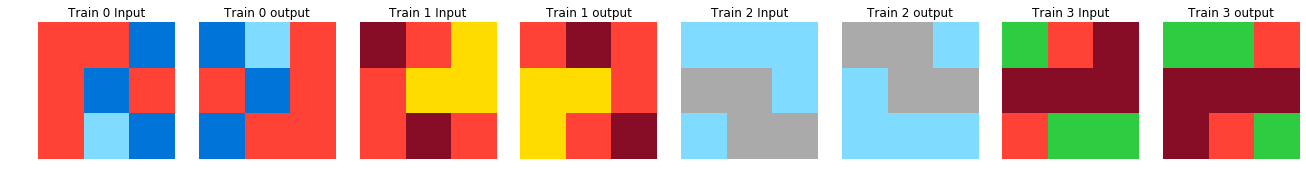

=====
99


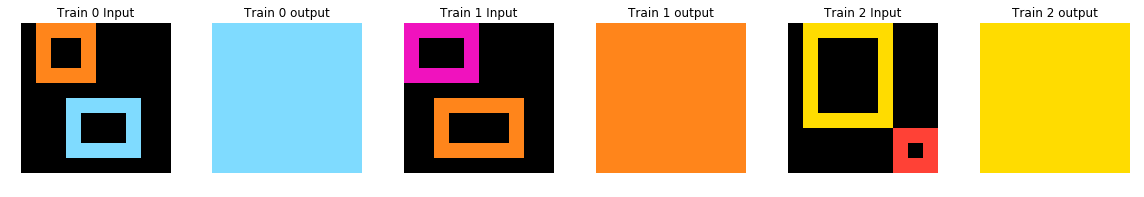

=====
128


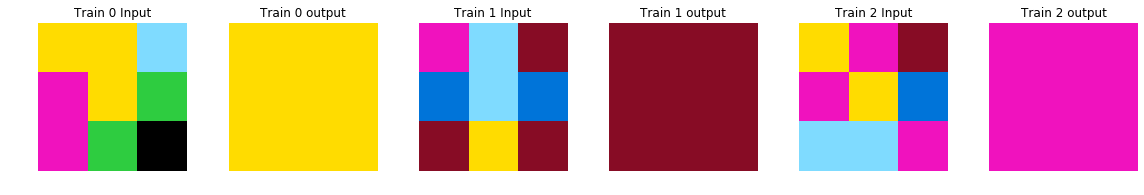

=====
139


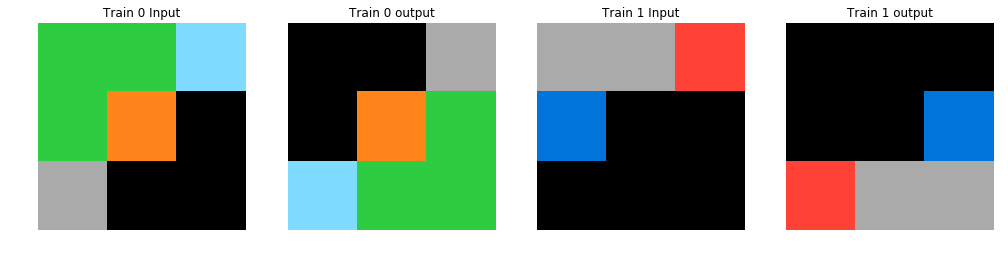

=====
149


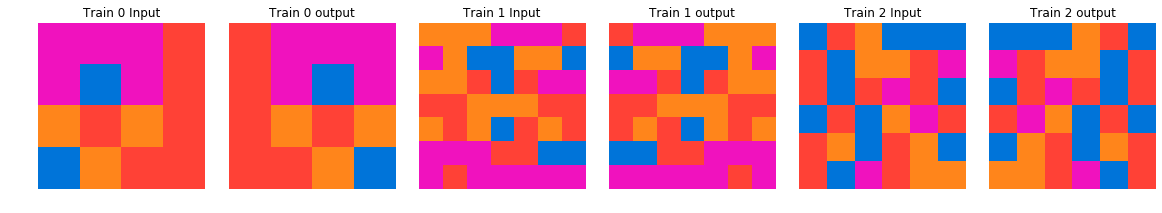

=====
154


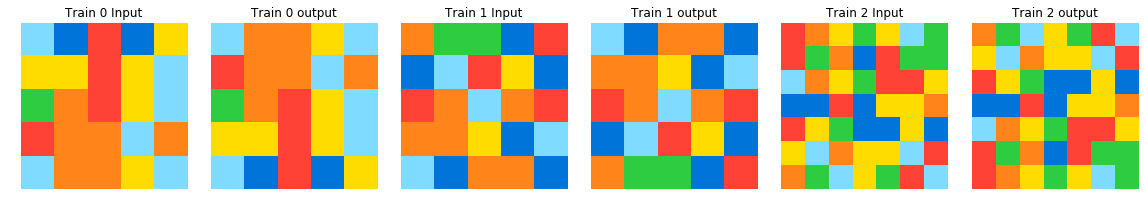

=====
178


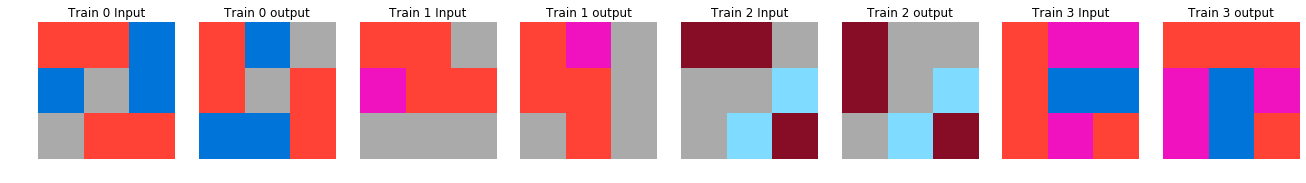

=====
222


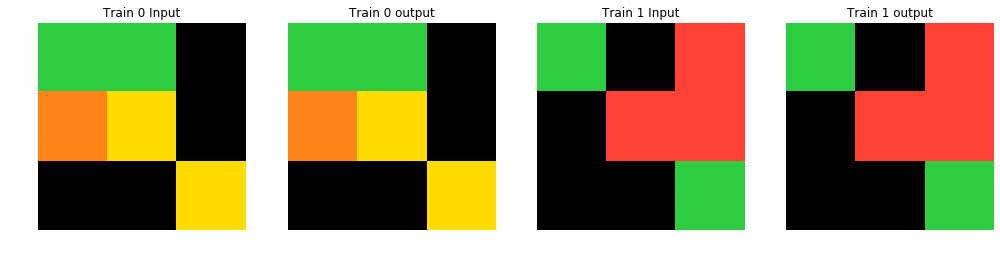

=====
240


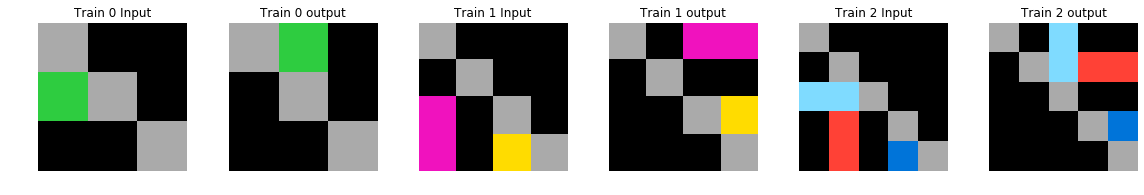

=====
266


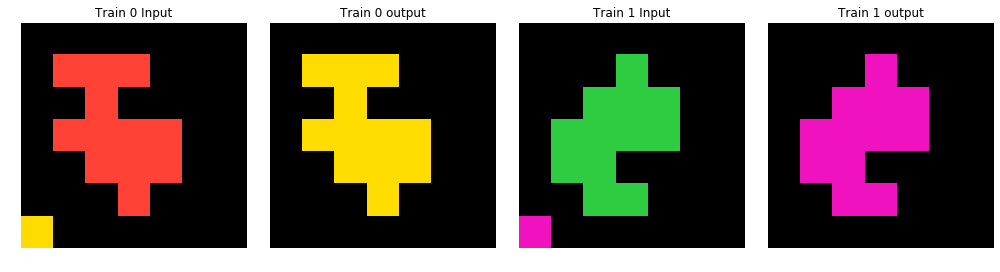

=====
268


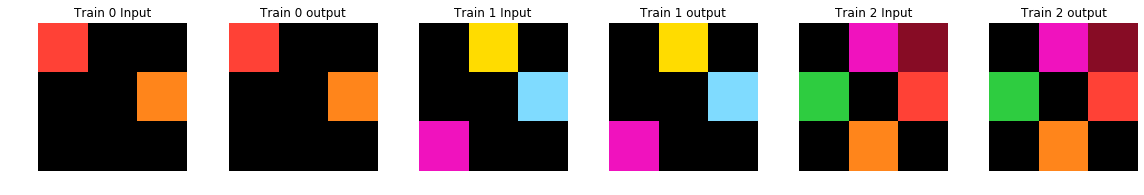

=====
275


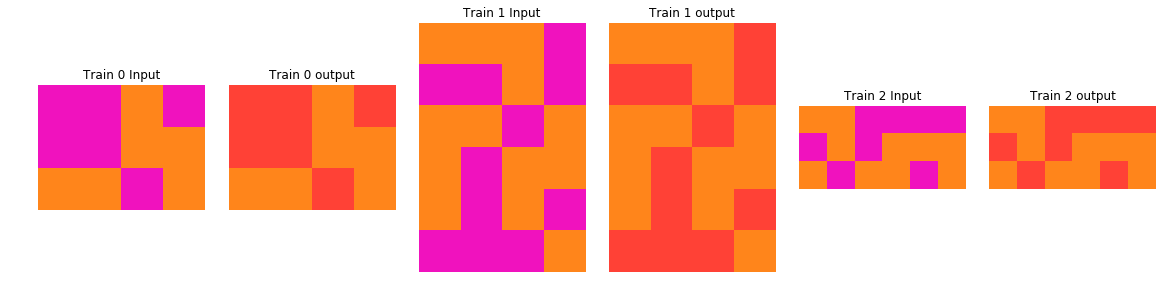

=====
288


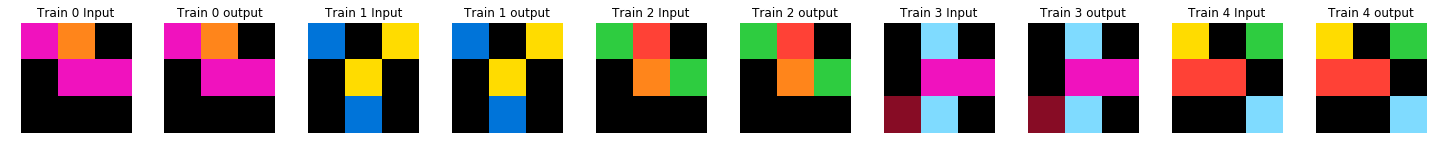

=====
306


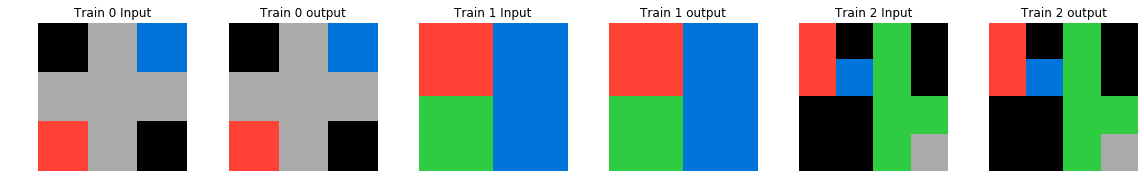

=====
308


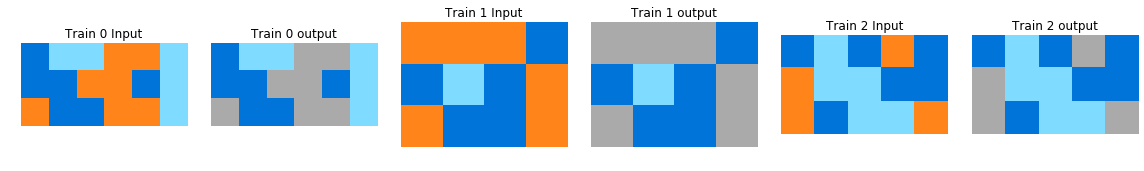

=====
336


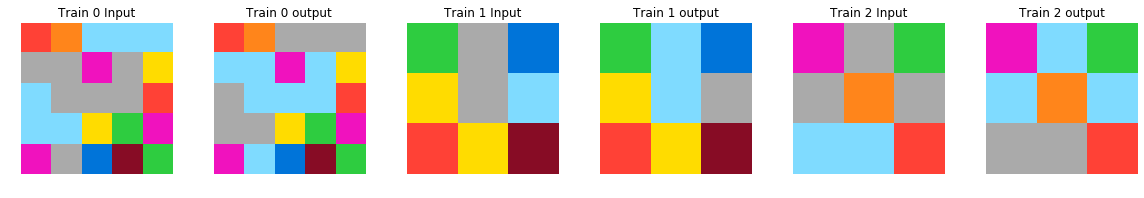

=====
379


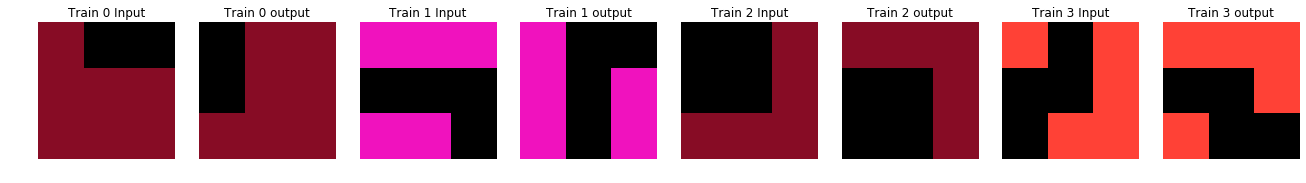

=====
388


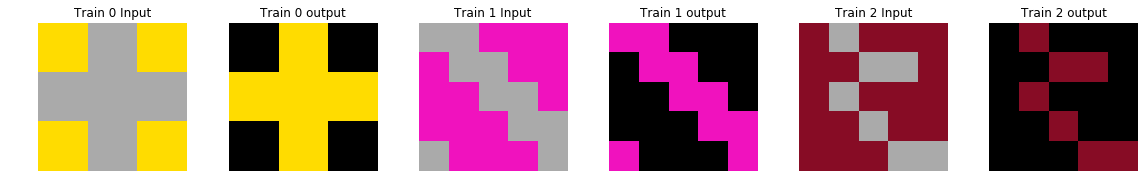

=====


In [22]:
for n in screening_results['passed_all_testinputs']:
    print(n)
    plot_task(tt[n])
    print('=====')

In [ ]:
for n in range(400):
    if previous_analysis[n].dimension_status != 'deduced'and previous_analysis[n].dimension_status != 'undeduced':
        print(n)
        plot_task(tt[n])
        print(previous_analysis[n].dimension_status)
        print('===')

In [ ]:
previous_analysis[1].traininputs_prkn == previous_analysis[1].cur_x_train

In [ ]:
previous_analysis[1].cur_x_train

In [ ]:
previous_analysis[106].traininputs_prkn[0].shape

In [ ]:
previous_analysis[106].trainoutputs_tokenized[0].shape

In [ ]:
to_hook_up = [1, 345, 119, 186, 250, 293, 337]
to_figure_out = [345, 48, 66, 105, 129, 151, 217, 290]

In [ ]:
for n in to_hook_up + to_figure_out:
    print(n)
    plot_task(tt[n])
    this_task = previous_analysis[n]
    l1, l2, l3 = this_task.get_features()
    print('input features:', l1[0])
    print('output:', l2[0])
    if type(l2[0]) != str:
        print('output shape:', l2[0].shape)
    print('objective:', this_task.objective[0])
    if this_task.is_similar_dim:
        print('running_objective:', this_task.running_objective[0])
    print('====')

In [ ]:
knowns = load_serialized('assets/solved_indices_for_the_day.pkl')

In [ ]:
# fix test_token_to_colors 44, 52, 261, 265! this is only unexplaied 1% of objectification failure.
for case in [44, 52, 261, 265]:
    plot_task(tt[case], True)
    print('=====')

In [ ]:
# current_situation = 'screening ' + what_to_try
# current_situation = 'passed_all_traininputs'
# current_situation = 'passed_all_testinputs'
# current_situation = 'passed_some_testinputs'
# current_situation = 'unpassed_all_testinputs'
# current_situation = 'passed_some_traininputs'
# current_situation = 'unpassed_all_traininputs'

In [ ]:
# tokenized_graph, in_, x_situation, y_situation, frequency_graph, sorted_frequency_graph, edge_situation, neighbor_situation
#         0         1       2            3              4                  5                    6                7

In [ ]:
possibles = 0
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_similar_dim and this_task.running_objective[0] != this_task.objective[0] and len(this_task.running_objective[0]) <= 15:
        print(n)
        possibles += 1
        print(this_task.objective_status)
        print(this_task.is_similar_dim)
        print(this_task.dimension_status)
        print('running_objective:', this_task.running_objective)
        print('test_objective:', this_task.test_objective)
        plot_task(tt[n])
        print('====')
    elif this_task.is_similar_dim == False and this_task.objective[0] != this_task.test_objective[0]and len(this_task.objective[0]) <= 15:
        print(n)
        possibles += 1
        print(this_task.objective_status)
        print(this_task.is_similar_dim)
        print(this_task.dimension_status)
        print('objective:', this_task.objective)
        print('test_objective:', this_task.test_objective)
        plot_task(tt[n])
        print('====')

In [ ]:
possibles